# Inspecting Very Large Array - ACS Nearby Galaxy Survey Treasury (VLA-ANGST) Spectral Cube Data

## 1.1 Objective
This notebook documents inspection of VLA-ANGST radio observations concerning **NGC 3741**: an irregular dwarf galaxy located about 10 million light-years (3.2 Mpc from Earth) in the constellation Ursa Major. NGC 3741 is notable for its exceptionally extended disk of neutral atomic hydrogen (HI), which reaches much beyond its visible stellar component seen in optical images. Its rotation also indicates that the galaxy is strongly dominated by dark matter.

In this notebook, I inspect the structure of the HI spectral cube to observe the progression of neutral hydrogen emission through radial-velocity channels. The unique properties of NGC 3741's seemingly invisible and much larger gas structure allow radio observations to reveal more information about its rotation curve, mass and the presence of dark matter.

![NGC 3741 imaged by the HST](ngc3741.png)  
*NGC 3741 as imaged by the Hubble Space Telescope*

## 1.2 Background
Although NGC 3741 has a relatively small and faint stellar component (as we can observe in the above optical image by the Hubble Space Telescope), it is surrounded by an exceptionally extended disk of neutral atomic hydrogen (HI). Gentile et al. (2007) traced this disk to a radius of approxmiately 6.6-7 kpc, corresponding to about 42 B-band exponential scale lengths (meaning on the B-band exponential scale length, the gas disk is about 42 times the typical size scale of its visible starlight) and roughly 15 times the conventional optical radius $(R_{25})$. At the time of the study, this was the most extended galactic rotation curve measured relative to the size of the visible stellar disk.

### Selected Properties

| Property                               |                                         Reported value |  
| -------------------------------------- | -----------------------------------------------------:
| Galaxy type                            |                                        Dwarf irregular |
| Adopted distance                       |                                      $(3.0 \pm 0.3) Mpc$ | 
| Absolute B-band magnitude              |                                           $(M_B=-13.13)$ | 
| B-band luminosity                      |                                $(2.7\times10^7,L_\odot)$ | 
| Systemic H I velocity                  |                              $(228\ \mathrm{km\,s^{-1}})$ |
| Optical radius, (R_{25})               |                                               $(30.7'')$ | 
| Maximum traced H I radius              |                                    $ (6.6\text{–}7) kpc$ | 
| Relative H I extent                    | $(42) B-band scale lengths, or ≈ (15R_{25})$ | 
| Integrated H I flux                    |                          $(59.6\ \mathrm{Jy\,km\,s^{-1}})$ | 
| H I mass                               |                                $(1.3\times10^8,M_\odot)$ | 
| Total gas mass, including helium       |                               $ (1.7\times10^8,M_\odot)$ | 
| Characteristic H I velocity dispersion |                  ≈ $(6\ \mathrm{km\,s^{-1}})$ | D
| Non-circular motions                   |        ≈ $(5\text{–}13\ \mathrm{km\,s^{-1}})$ | 
| H I morphology                         |                   strong; about a symmetric warp |

*The values above were reported by Gentile et al. (2007) using Westerbork Synthesis Radio Telescope observations and associated modeling. They are included as background values and were not independently measured in this notebook.*

## 1.3 Data Values
The data analyzed in this project were obtained from the [VLA-ANGST survey](https://science.nrao.edu/science/surveys/vla-angst), a National Radio Astronomy Observatory (NRAO) Large Program that used the Very Large Array (VLA) to observe the 21 cm emission line of neutral atomic hydrogen (HI) in 35 nearby galaxies located within approximately 4 Mpc (Ott et al., 2012).

For this project, I use the natural-weighted HI data cube of NGC 3741. Each pixel in a spatial plane of the cube corresponds to a position on the sky and each spectral channel represents a range of line-of-sight velocities (RA, Declination, radial velocity). The voxel values measure HI line brightness in units of Jy beam⁻¹.  

The data cube has not been corrected for primary-beam attenuation, and its velocity channels are expressed in the Local Standard of Rest (LSR) reference frame (Ott et al., 2012; NRAO, n.d.).

In [1]:
%pip install astropy spectral_cube matplotlib numpy
from spectral_cube import SpectralCube

cube = SpectralCube.read(
    "radio_data/VLA-ANGST_HI_NGC3741-nat-cube.fits.gz"
)

print(cube)
print("cube shape:", cube.shape)
print("spectral axis:", cube.spectral_axis)


[notice] A new release of pip is available: 26.1.2 -> 26.2.1
[notice] To update, run: pip3 install --upgrade pip
Note: you may need to restart the kernel to use updated packages.
SpectralCube with shape=(115, 1024, 1024) and unit=Jy / beam:
 n_x:   1024  type_x: RA---SIN  unit_x: deg    range:   173.721486 deg:  174.329586 deg
 n_y:   1024  type_y: DEC--SIN  unit_y: deg    range:    45.069878 deg:   45.496127 deg
 n_s:    115  type_s: VOPT-F2W  unit_s: m / s  range:   154187.126 m / s:  301268.539 m / s
cube shape: (115, 1024, 1024)
spectral axis: [154187.12639818 155476.68743172 156766.25955374 158055.84276436
 159345.43706371 160635.04245205 161924.65892935 163214.28649588
 164503.92515172 165793.574897   167083.23573198 168372.90765662
 169662.59067125 170952.28477586 172241.98997065 173531.70625586
 174821.43363144 176111.17209772 177400.92165468 178690.68230258
 179980.45404156 181270.23687167 182560.03079318 183849.83580608
 185139.65191063 186429.47910698 187719.31739519 189009

## 1.4 First Look
I have defined cube with the shape of: `cube[velocity channel, vertical px, horizontal px]`, specifically with specs `cube.shape = (115, 1024, 1024)`, meaning that the cube contains 115 separate "2D" images that each measure HI emission at a different radial velocity.

This data cube therefore is described by approximately 115 x 1024 x 1024 = 120,586,240 voxels. 

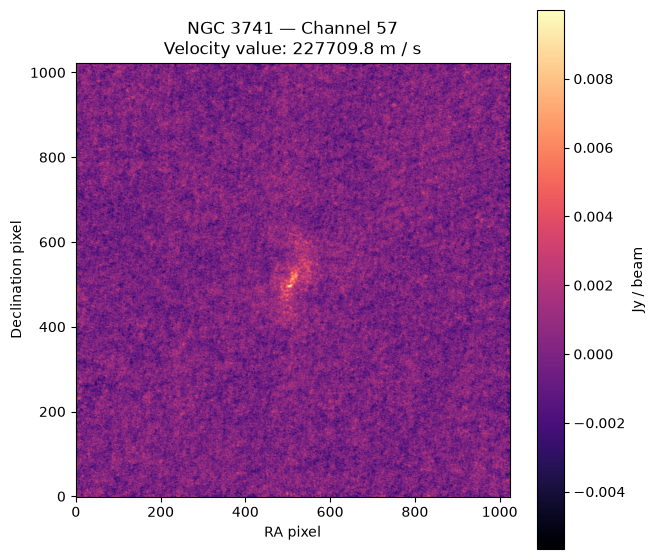

In [2]:
import matplotlib.pyplot as plt

channel_number = cube.shape[0] // 2
channel = cube[channel_number]

plt.figure(figsize=(7, 7))
plt.imshow(channel.value, origin="lower", cmap="magma")
plt.colorbar(label=str(channel.unit))
plt.title(
    f"NGC 3741 — Channel {channel_number}\n"
    f"Velocity value: {cube.spectral_axis[channel_number]:.1f}"
)
plt.xlabel("RA pixel")
plt.ylabel("Declination pixel")
plt.show()

## 1.4 Cont...
In the above code I selected the middle channel:
`channel_number = cube.shape[0] // 2`

...which selects the value of 115, then performs integer division by 2 = 57. 
Then, I extracted the 2D image from that channel:
`channel = cube[channel_number]`
or 
`channel = cube[57]`

After creating a figure (or an empty area for plotting), I displayed the 2D image of this spatial velocity channel:
```
plt.imshow(
    channel.value,   #retrieve values
    origin="lower",  #sets origin to lower-left
    cmap="magma"     #choose color map
)
```

Then I created a color bar, added a title, labeled the axes, and finally displayed the plot.

### Observations
Channel 57 corresponds to a radial velocity of approximately 227.7 $\mathrm{km\,s^{-1}}$, which is close to the published systemic velocity of NGC 3741 by Gentile et al.
A localized region of comparatively bright HI emission is present around the center of the image. It has an elongated and slightly irregular shape that suggests that the neutral hydrogen at this spatial velocity is not confined to one certain region but is spread across several neighboring spatial pixels. Additionally, there appears to be greater HI flux density in Jy $beam^{-1}$ towards the center of the image. However, it is tenuous to make an argument for or against a central black hole as additional channels must be compared to determine how the detected emission changes in position and structure across the velocity range.

Most of the surrounding field exhibits weaker, grain-like fluctuations in HI flux that are likely dominated by observational noise. This initial "first look" demonstrates that the examination of NGC 3741's spectral cube across all spatial velocity channels requires the optimization of noise levels.

## 1.5 Inspecting the Spectral Axis
To determine which velocity channels contain detectable HI emission, I summed the intensity across the spatial pixels of each channel. The resulting spectrum provides an estimate of the galaxy's velocity range.

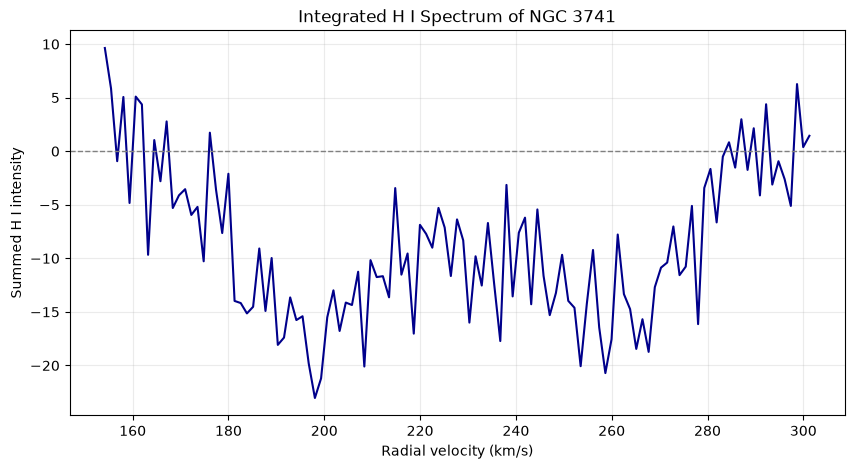

In [3]:
import numpy as np
from astropy import units as u

velocities = cube.spectral_axis.to_value(u.km / u.s)

cube_data = cube.unmasked_data[:].value

integrated_intensity = np.nansum(cube_data, axis=(1, 2))

plt.figure(figsize=(10, 5))

plt.plot(
    velocities,
    integrated_intensity,
    color="darkblue",
    linewidth=1.5
)

plt.axhline(0, color="gray", linestyle="--", linewidth=1)

plt.xlabel("Radial velocity (km/s)")
plt.ylabel("Summed H I intensity")
plt.title("Integrated H I Spectrum of NGC 3741")

plt.grid(alpha=0.25)
plt.show()

In [4]:
peak_channel = np.nanargmax(integrated_intensity)
peak_velocity = velocities[peak_channel]

print("Strongest channel:", peak_channel)
print(f"Velocity: {peak_velocity:.1f} km/s")

Strongest channel: 0
Velocity: 154.2 km/s


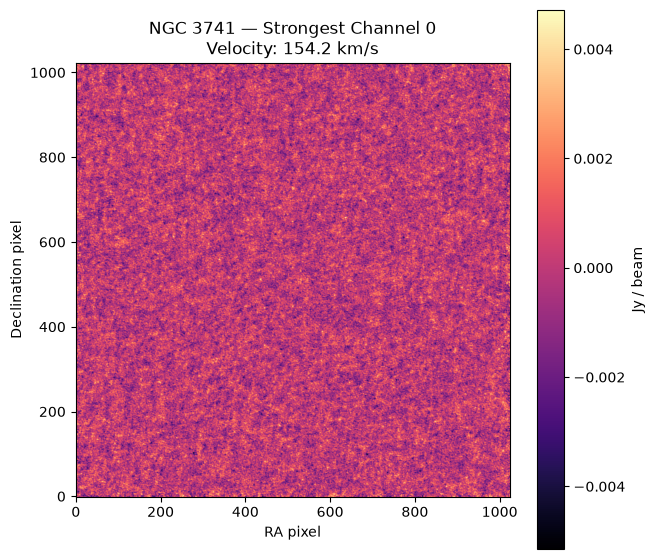

In [5]:
channel = cube[peak_channel]

plt.figure(figsize=(7, 7))

plt.imshow(
    channel.value,
    origin="lower",
    cmap="magma"
)

plt.colorbar(label=str(channel.unit))

plt.title(
    f"NGC 3741 — Strongest Channel {peak_channel}\n"
    f"Velocity: {peak_velocity:.1f} km/s"
)

plt.xlabel("RA pixel")
plt.ylabel("Declination pixel")
plt.show()

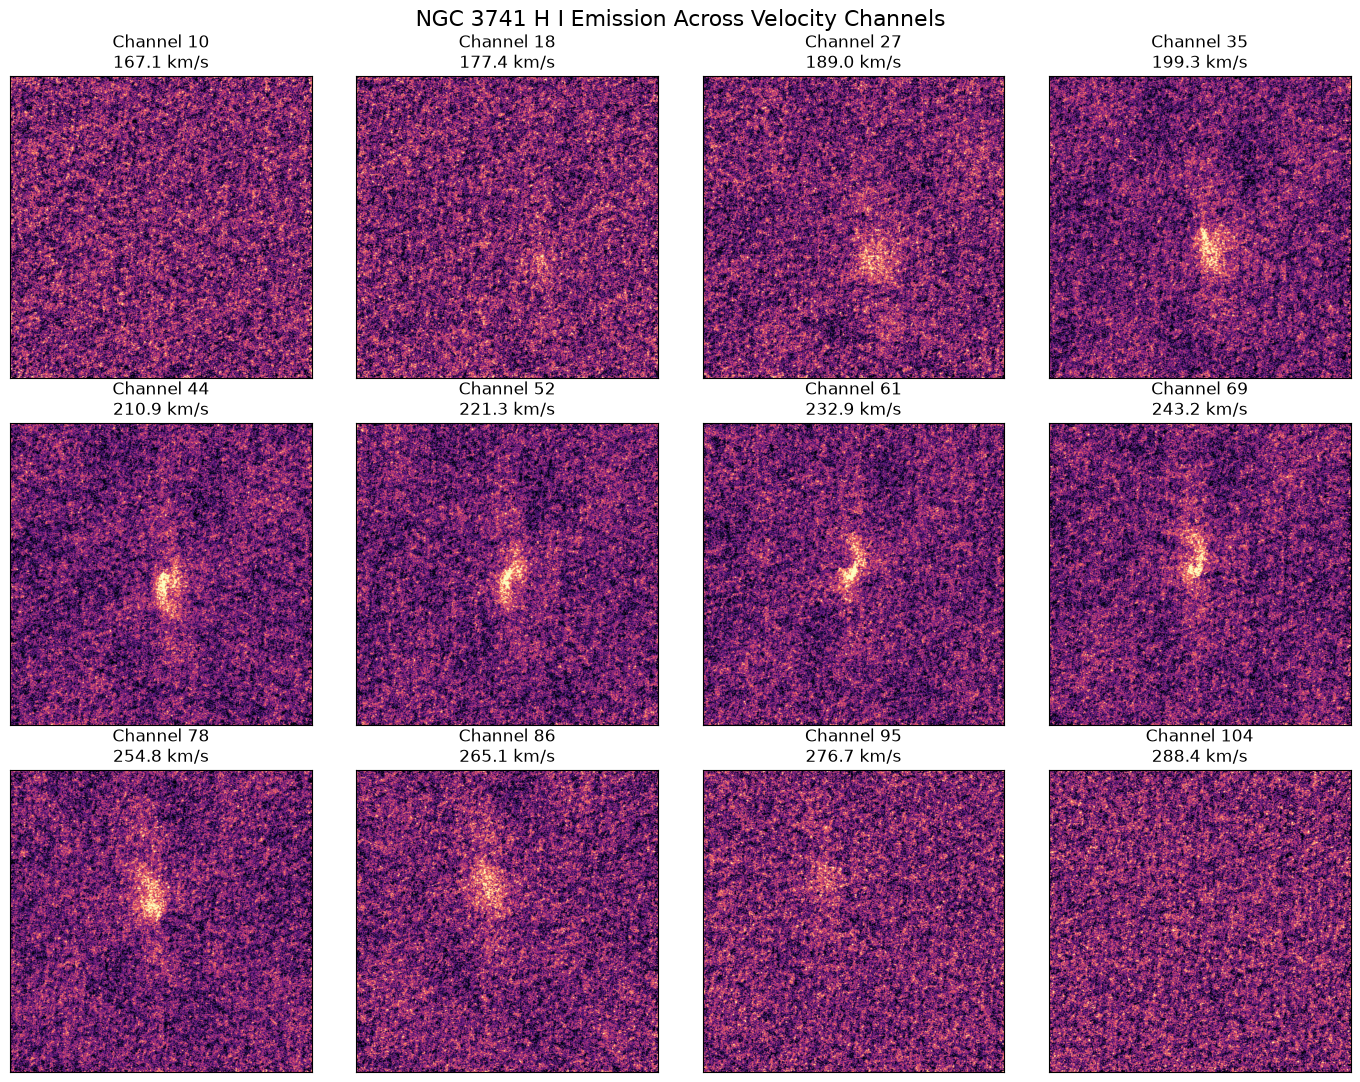

In [6]:
channel_numbers = np.linspace(
    10,
    cube.shape[0] - 11,
    12,
    dtype=int
)

fig, axes = plt.subplots(
    3,
    4,
    figsize=(14, 11)
)

for ax, channel_number in zip(axes.flat, channel_numbers):
    image = cube[channel_number].value

    lower = np.nanpercentile(image, 5)
    upper = np.nanpercentile(image, 99.8)

    ax.imshow(
        image,
        origin="lower",
        cmap="magma",
        vmin=lower,
        vmax=upper
    )

    velocity = velocities[channel_number]

    ax.set_title(
        f"Channel {channel_number}\n"
        f"{velocity:.1f} km/s"
    )

    ax.set_xticks([])
    ax.set_yticks([])

plt.suptitle(
    "NGC 3741 H I Emission Across Velocity Channels",
    fontsize=16
)

plt.tight_layout()
plt.show()

## Observations of H I emission through velocity channels
Detectable H I emission is concentrated primarily between approximately 189 and 265 km s(^{-1}), while the lowest and highest-velocity channels are dominated by background noise. The midpoint of this preliminary emission range is approximately 227 km s(^{-1}), close to the published systemic velocity of 228 km s(^{-1}) for NGC 3741.

A systematic spatial shift in the H I emission is visible across the channel sequence. At velocities below the systemic velocity, the emission is displaced toward the lower-right portion of the image. As velocity increases, it moves through the central region and becomes displaced toward the upper-left at velocities above the systemic velocity. This continuous velocity gradient is consistent with ordered rotation in an inclined gas disk. Relative to the galaxy’s systemic motion, the lower-velocity emission represents the approaching side of the disk, while the higher-velocity emission represents the receding side.

The morphology of the emission also changes between channels. It appears relatively compact at some extreme velocities and broader or more curved near the central velocity channels. This behavior is expected when different regions of a rotating disk contribute to different line-of-sight velocities. The changing curvature and apparent asymmetry may also contain evidence of the known warp or non-circular gas motions in NGC 3741; however, these possibilities cannot be established from visual inspection alone. Confirmation would require noise masking, moment maps, a position–velocity diagram, and comparison with a rotating-disk model.

Because each channel in this preliminary figure was contrast-scaled independently, the apparent brightnesses of different panels cannot be compared quantitatively. The figure therefore demonstrates the changing spatial distribution of emission with velocity, but it does not yet determine which channel contains the greatest total H I flux.

### References

1. Gentile, G., Salucci, P., Klein, U., & Granato, G. L. (2007). “NGC 3741: the dark halo profile from the most extended rotation curve.” *Monthly Notices of the Royal Astronomical Society*, **375**, 199–212. https://doi.org/10.1111/j.1365-2966.2006.11283.x

2. Ott, J., Stilp, A. M., Warren, S. R., et al. (2012). “VLA-ANGST: A high-resolution H I survey of nearby dwarf galaxies.” *The Astronomical Journal*, **144**, 123. https://doi.org/10.1088/0004-6256/144/4/123

National Radio Astronomy Observatory. (n.d.).
*The VLA-ANGST Survey*.
https://science.nrao.edu/science/surveys/vla-angst

National Radio Astronomy Observatory. (n.d.).
*VLA-ANGST data products*.
https://science.nrao.edu/science/surveys/vla-angst/data-products
Accessed August 8, 2026.